In [1]:
!pip install scikit-learn numpy matplotlib

### **Double Descent Phenomenon Implementation**

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

#### 1. Generate synthetic dataset

In [48]:
# -----------------------------
# 1. Generate synthetic dataset
# -----------------------------
def run(seed):
    np.random.seed(seed)

    n_train = 30
    n_test = 200

    X_train = np.random.randn(n_train, 1)
    X_test = np.random.randn(n_test, 1)

    def f(x):
        return np.sin(x)

    y_train = f(X_train) + 0.2 * np.random.randn(n_train, 1)
    y_test = f(X_test)

    max_features = 400
    W = np.random.randn(1, max_features)
    b = np.random.uniform(0, 2*np.pi, size=max_features)

    Phi_train_full = np.cos(X_train @ W + b)
    Phi_test_full = np.cos(X_test @ W + b)

    train_err, test_err = [], []

    for m in range(1, max_features + 1):
        scale = np.sqrt(m)
        Phi_train = Phi_train_full[:, :m] / scale
        Phi_test = Phi_test_full[:, :m] / scale

        model = Ridge(alpha=1e-8, fit_intercept=False)
        model.fit(Phi_train, y_train)

        train_err.append(mean_squared_error(y_train, model.predict(Phi_train)))
        test_err.append(mean_squared_error(y_test, model.predict(Phi_test)))

    return train_err, test_err



#### 2. Train models of increasing capacity

In [49]:
# -----------------------------
# 2. Train models of increasing capacity
# -----------------------------
# Average over seeds
runs = 10
all_tr, all_te = [], []

for s in range(runs):
    tr, te = run(s)
    all_tr.append(tr)
    all_te.append(te)

mean_tr = np.mean(all_tr, axis=0)
mean_te = np.mean(all_te, axis=0)



#### 3. Plot double descent curve

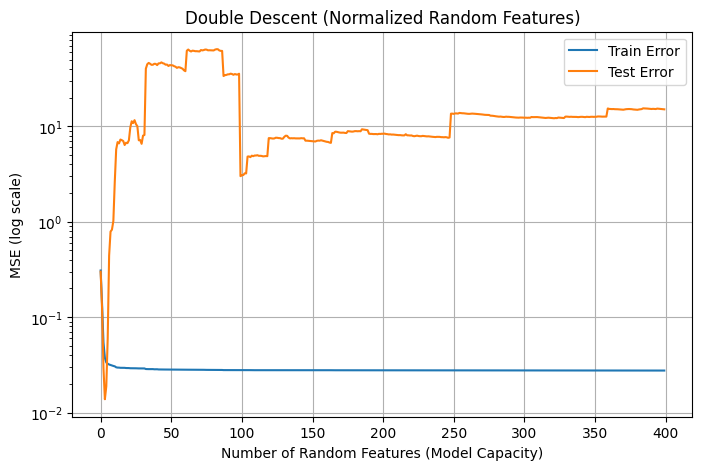

In [52]:
# -----------------------------
# 3. Plot double descent curve
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(mean_tr, label="Train Error")
plt.plot(mean_te, label="Test Error")
# plt.axvline(30, linestyle="--", label="Interpolation Threshold")

plt.yscale("log")
plt.xlabel("Number of Random Features (Model Capacity)")
plt.ylabel("MSE (log scale)")
plt.title("Double Descent (Normalized Random Features)")
plt.legend()
plt.grid(True)
plt.show()

